# Tamaño y severidad del incendio desde ángulos + distancia

**Pregunta:** ¿qué magnitudes del incendio se estiman desde ángulos + distancia, y con qué incertidumbre?

La distancia `D` viene de la triangulación (nb9). Acá sólo se convierte: píxeles → metros
(`W = D·dx/fx`), metros → volumen (cono truncado / elipsoide), llama → intensidad de Byram,
altura de pluma → potencia de Briggs. La lógica vive en `modulos/severidad.py` (backend,
float); el notebook sólo mide y grafica.

> Con distancia monocular (σD/D ~ 30 %) todo es **orden de magnitud**; con triangulación
> (~2 %) es **medición**. El volumen y Briggs elevan el error al cubo.


In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Raíz del banco = la carpeta que contiene `modulos/`.
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "modulos").is_dir()), None)
if RAIZ is None:
    raise RuntimeError(f"no encuentro 'modulos/' desde {Path.cwd()}")
sys.path.insert(0, str(RAIZ / "modulos"))

def ruta_salida(nombre):
    SAL = RAIZ / "salidas"
    SAL.mkdir(parents=True, exist_ok=True)
    return SAL / nombre

import severidad as sv
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

FX = 7273.0  # fx [px] OV2640 + 16 mm (nb8): f/p = 16 mm / 2.2 um


## 1 · Alto/ancho métricos: W = D·dx/fx

A 5 km, 1 px ≈ 0.69 m (nb8). Una columna de 14 px de ancho × 40 px de alto son ~10 × 28 m.
El error métrico hereda directo el de distancia: 2 % triangulado vs 30 % monocular.


columna joven: 1 km -> 1.9 x 5.5 m; 2 km -> 3.8 x 11.0 m; 5 km -> 9.6 x 27.5 m; 10 km -> 19.2 x 55.0 m
pluma desarrollada: 1 km -> 8.2 x 20.6 m; 2 km -> 16.5 x 41.2 m; 5 km -> 41.2 x 103.1 m; 10 km -> 82.5 x 206.2 m


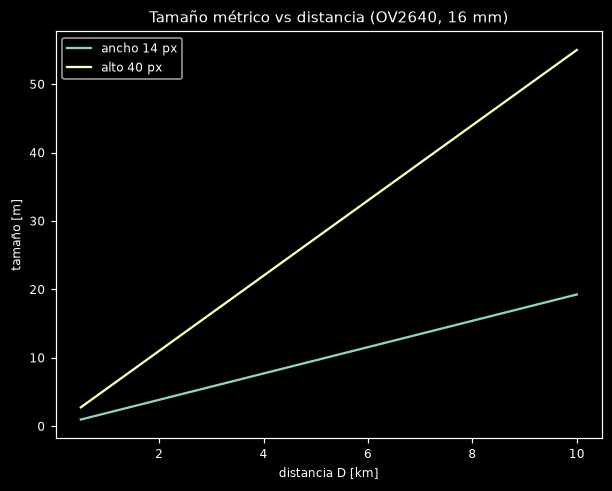

In [2]:
Ds = np.array([1000, 2000, 5000, 10000])
for dx, dy, etq in [(14, 40, "columna joven"), (60, 150, "pluma desarrollada")]:
    W = [sv.dim_metros(float(D), dx, FX) for D in Ds]
    H = [sv.dim_metros(float(D), dy, FX) for D in Ds]
    print(f"{etq}: " + "; ".join(f"{D/1000:.0f} km -> {w:.1f} x {h:.1f} m" for D, w, h in zip(Ds, W, H)))

D = np.linspace(500, 10000, 200)
fig, ax = plt.subplots()
for dx, etq in [(14, "ancho 14 px"), (40, "alto 40 px")]:
    ax.plot(D/1000, sv.dim_metros(D, dx, FX), label=etq)
ax.set_xlabel("distancia D [km]"); ax.set_ylabel("tamaño [m]")
ax.set_title("Tamaño métrico vs distancia (OV2640, 16 mm)"); ax.legend(); plt.show()


## 2 · Volumen: cono truncado vs elipsoide, y el error se eleva al cubo

`V ∝ D³·θw²·θh`: Monte Carlo con σD/D = 2 / 10 / 30 % (+ 5 % de segmentación angular).
Con 2 % el volumen sale al ~13 % (manda el 5 % de segmentación); con 30 % llega a ~84 %: orden de magnitud.


columna a 5 km: 9.6 x 27.5 m
cono truncado (r_base=W/4, r_top=W/2): 1167 m³
elipsoide (L_prof=W):                 1334 m³
sigmaD/D = 2 %  ->  sigmaV/V = 13 %
sigmaD/D = 10 %  ->  sigmaV/V = 32 %
sigmaD/D = 30 %  ->  sigmaV/V = 84 %


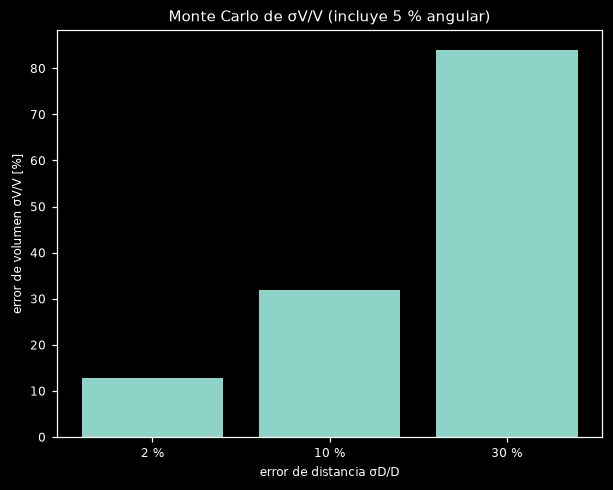

In [3]:
W, H = sv.dim_metros(5000, 14, FX), sv.dim_metros(5000, 40, FX)
print(f"columna a 5 km: {W:.1f} x {H:.1f} m")
print(f"cono truncado (r_base=W/4, r_top=W/2): {sv.vol_cono_truncado(H, W/4, W/2):.0f} m³")
print(f"elipsoide (L_prof=W):                 {sv.vol_elipsoide(W, H):.0f} m³")

sigs = [0.02, 0.10, 0.30]
errs = [sv.mc_vol_rel(s) for s in sigs]
for s, e in zip(sigs, errs):
    print(f"sigmaD/D = {s*100:.0f} %  ->  sigmaV/V = {e*100:.0f} %")
fig, ax = plt.subplots()
ax.bar([f"{s*100:.0f} %" for s in sigs], [e*100 for e in errs])
ax.set_xlabel("error de distancia σD/D"); ax.set_ylabel("error de volumen σV/V [%]")
ax.set_title("Monte Carlo de σV/V (incluye 5 % angular)"); plt.show()


## 3 · Byram: Lf ↔ I y tabla de severidad

`I = 259.83·Lf^2.174` [kW/m] (Byram 1959 / Alexander 1982).

> ⚠️ **Validez:** sólo a < ~2 km o con llama sobre el dosel. A más de 3–4 km el monte
> ocluye la base (§4.2 del informe) y el `blooming` nocturno infla el área: la tabla
> clasifica, no mide.


Lf = 0.5 m  ->  I =     58 kW/m  [Baja] ataque directo con herramientas manuales
Lf = 1.0 m  ->  I =    260 kW/m  [Baja] ataque directo con herramientas manuales
Lf = 2.0 m  ->  I =   1173 kW/m  [Moderada] difícil a mano; autobombas / cortafuegos
Lf = 3.0 m  ->  I =   2831 kW/m  [Alta] ataque directo imposible; maquinaria + medios aéreos
Lf = 4.0 m  ->  I =   5291 kW/m  [Extrema] eruptivo; sólo flancos defensivos


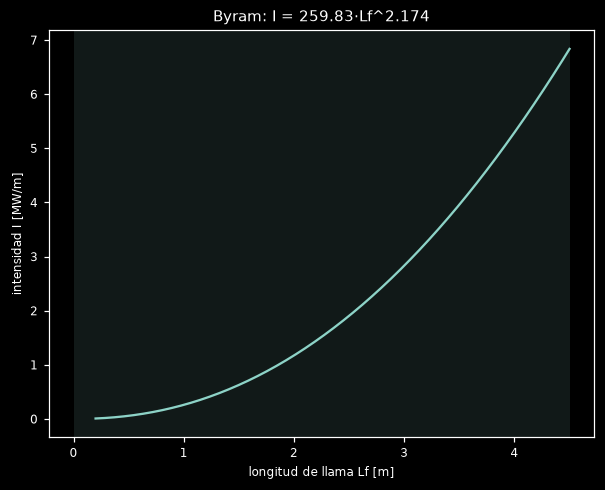

In [4]:
for Lf in [0.5, 1.0, 2.0, 3.0, 4.0]:
    clase, I, resp = sv.clase_severidad(Lf)
    print(f"Lf = {Lf:.1f} m  ->  I = {I:6.0f} kW/m  [{clase}] {resp}")

Lf = np.linspace(0.2, 4.5, 200)
fig, ax = plt.subplots()
ax.plot(Lf, [sv.byram_I(x)/1000 for x in Lf])
for x0, x1 in [(0, 1), (1, 2.5), (2.5, 3.5), (3.5, 4.5)]:
    ax.axvspan(x0, x1, alpha=0.12)
ax.set_xlabel("longitud de llama Lf [m]"); ax.set_ylabel("intensidad I [MW/m]")
ax.set_title("Byram: I = 259.83·Lf^2.174"); plt.show()


## 4 · Briggs: de Δh_obs a Qc, con viento externo

`Fb = (Δh·U/(1.6·x^{2/3}))³`, `Qc = Fb·π·ρ·cp·T/g`, ρ desde el BME280 (T, P).
El **viento U es entrada externa** (estación/GFS): el BME280 no lo mide.
`Fb ∝ (Δh·U)³`: 20 % de error en Δh o U → ~70 % en Qc. Orden de magnitud, no medición.


BME280 (32 °C, 1008 hPa): rho = 1.151 kg/m³
Δh=120 m, U=5 m/s, x=300 m -> Fb = 585.9 m⁴/s³, Qc = 66.2 MW, biomasa = 5.9 kg/s
Δh x 0.8: Qc = 34.1 MW (51 % del base)
Δh x 1.0: Qc = 66.6 MW (100 % del base)
Δh x 1.2: Qc = 115.0 MW (173 % del base)


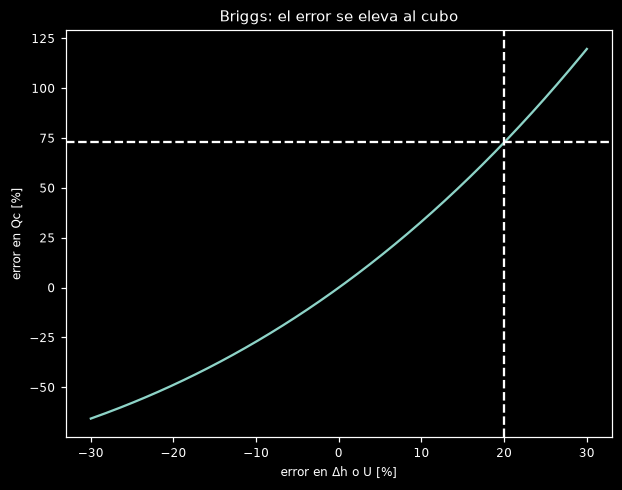

In [5]:
rho = sv.rho_aire(T_c=32.0, P_hpa=1008.0)
print(f"BME280 (32 °C, 1008 hPa): rho = {rho:.3f} kg/m³")
Fb = sv.briggs_Fb(dh_m=120.0, U_ms=5.0, x_m=300.0)
Qc = sv.briggs_Qc(Fb, T_c=32.0, P_hpa=1008.0)
print(f"Δh=120 m, U=5 m/s, x=300 m -> Fb = {Fb:.1f} m⁴/s³, Qc = {Qc/1e6:.1f} MW, "
      f"biomasa = {sv.biomasa_kgs(Qc):.1f} kg/s")

# Sensibilidad cúbica: ±20 % en Δh (o en U; no en los dos a la vez)
base = sv.briggs_Qc(sv.briggs_Fb(120.0, 5.0, 300.0))
for f in [0.8, 1.0, 1.2]:
    q = sv.briggs_Qc(sv.briggs_Fb(120.0*f, 5.0, 300.0))
    print(f"Δh x {f}: Qc = {q/1e6:.1f} MW ({q/base*100:.0f} % del base)")

fig, ax = plt.subplots()
e = np.linspace(-30, 30, 200)
ax.plot(e, ((1+e/100)**3 - 1)*100)
ax.axvline(20, ls="--"); ax.axhline(73, ls="--")
ax.set_xlabel("error en Δh o U [%]"); ax.set_ylabel("error en Qc [%]")
ax.set_title("Briggs: el error se eleva al cubo"); plt.show()


## 5 · Exportar ejemplo y conclusión

Se guarda `salidas/severidad_ejemplo.json` con un caso a 5 km.

**Conclusión:** con D triangulada (2 %) el tamaño y el volumen son **medición**
(~13 % en V) y la severidad de Byram clasifica bien de cerca; Briggs da la potencia
en MW como **orden de magnitud** (el viento externo y Δh mandan al cubo). Con D
monocular (30 %) hasta el volumen es sólo orden de magnitud: sin segundo nodo no hay
severidad cuantitativa, sólo detección + cota gruesa.


In [6]:
ej = sv.ejemplo()
p = ruta_salida("severidad_ejemplo.json")
p.write_text(json.dumps(ej, indent=2, ensure_ascii=False))
print(p, "->", json.dumps(ej, ensure_ascii=False)[:200], "...")


/home/gabi/Documentos/FaCENA/proyecto_final/Desarrollo/Pruebas/salidas/severidad_ejemplo.json -> {"D_m": 5000.0, "W_pluma_m": 9.6, "H_pluma_m": 27.5, "V_cono_m3": 1167.0, "V_elipsoide_m3": 1334.0, "mc_vol_rel_2pct": 0.128, "mc_vol_rel_10pct": 0.319, "mc_vol_rel_30pct": 0.84, "Byram_Lf_m": 1.5, "B ...
